# Predicting Vinho Verde Wine Quality Using Exploratory Data Analysis and Machine Learning

## Project Overview

The dataset that was used in this project is the Wine Quality dataset and it contains two datasets that are related to the red and white variants of the Portuguese "Vinho Verde" wine.

The goal of this project is to understand which factors influence the wine quality and develop some predictive models using machine learning techniques.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import altair as alt

## 2. Loading and Checking the Datasets

In [2]:
# Load Datasets
red = pd.read_csv("winequality-red-26.csv", sep=';')
white = pd.read_csv("winequality-white-26.csv", sep=';')

# Clean Column Names
red.columns = red.columns.str.strip()
white.columns = white.columns.str.strip()

# Check Red Dataset
print(red.head())
print(red.info())
print(red.describe())

# Check White Dataset
print(white.head())
print(white.info())
print(white.describe())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        6  
1      9.8        6  
2      9.8        6 

### 2.1 Data Summary

The dataset contains 1,599 red wine samples and 4,898 white wine samples. Each has 11 physicochemical properties (acidity, sulfates, alcohol content, etc.) and a quality rating. I ended up checking the data structure because it helps identify any missing values and data types before proceeding with analysis.


## 3. Exploratory Analysis Of Red And White Wines

I started off by wanting to describe the distribution of wine quality across all samples and compare the quality distributions. For this I created histogram to illustrate the distribution of quality for red and white seperately.



### 3.1 Red Wine Quality Distribution

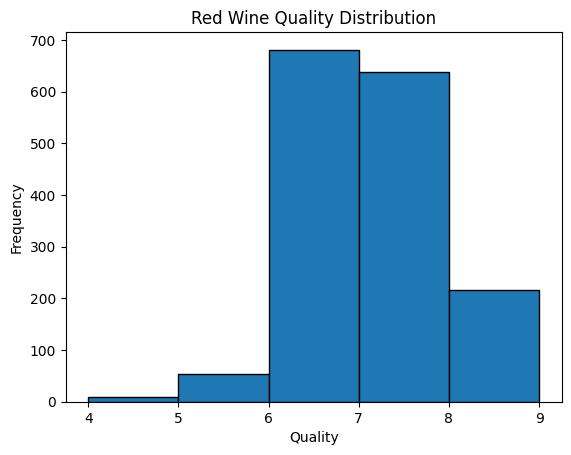

In [3]:
# Extract Quality Columns
redQuality = red["quality"]
whiteQuality = white["quality"]

# Histogram For Red Wine Quality
plt.figure()
plt.hist(redQuality, bins=range(4, 10), edgecolor='black') 
plt.title("Red Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()

### 3.2 White Wine Quality Distribution

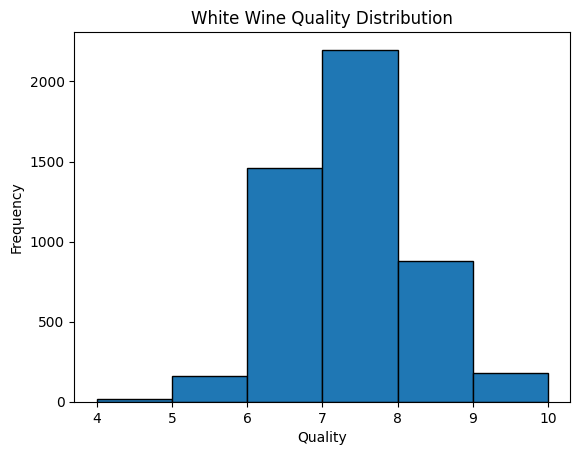

In [4]:
# Histogram For White Wine Quality
plt.figure()
plt.hist(whiteQuality, bins=range(4, 11), edgecolor='black')
plt.title("White Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()

### 3.3 Conclusion Of Histograms

Most wines are concentrated around the middle quality scores, meaning very low and very high quality wines are less common.

White wines have a higher average quality score (6.88) compared to red wines (6.64). The most common score for white wine is 7, while for red wine it is 6. 

White wines also have a wider range of quality scores, reaching a maximum of 10, whereas red wines only reach 9. In addition, a larger proportion of white wines fall into higher quality categories (8 and above) compared to red wines.




## 4. Alcohol Categorisation And Analysis

In [5]:
# Create Red Alcohol Content With Average And Standard Deviation
redAlcoholContent = red["alcohol"]
redAverageAlcoholContent = np.average(redAlcoholContent)
redStandardDeviationAlcoholContent = np.std(redAlcoholContent)

# Create White Alcohol Content With Average And Standard Deviation
whiteAlcoholContent = white["alcohol"]
whiteAverageAlcoholContent = np.average(whiteAlcoholContent)
whiteStandardDeviationAlcoholContent = np.std(whiteAlcoholContent)

# Create Red Conditions For alcoholCategory
conditionsRed = [
    (red["alcohol"] < (redAverageAlcoholContent - redStandardDeviationAlcoholContent)),
    (red["alcohol"] >= (redAverageAlcoholContent - redStandardDeviationAlcoholContent)) & (red["alcohol"] <= (redAverageAlcoholContent + redStandardDeviationAlcoholContent)),
    (red["alcohol"] > (redAverageAlcoholContent + redStandardDeviationAlcoholContent))
]

# Create White Conditions For alcoholCategory
conditionsWhite = [
    (white["alcohol"] < (whiteAverageAlcoholContent - whiteStandardDeviationAlcoholContent)),
    (white["alcohol"] >= (whiteAverageAlcoholContent - whiteStandardDeviationAlcoholContent)) & (white["alcohol"] <= (whiteAverageAlcoholContent + whiteStandardDeviationAlcoholContent)),
    (white["alcohol"] > (whiteAverageAlcoholContent + whiteStandardDeviationAlcoholContent))
]

# Create Values For alcoholCategory
values = ['low', 'mid', 'high']

# Create alcoholCategory Column For Red And White Datasets
red["alcohol_cat"] = np.select(conditionsRed, values, default="mid")
white["alcohol_cat"] = np.select(conditionsWhite, values, default="mid")

# Summary Statistics For Red Wine Quality By alcoholCategory
print(red.groupby("alcohol_cat")["quality"].describe())

# Summary Statistics For White Wine Quality By alcoholCategory
print(white.groupby("alcohol_cat")["quality"].describe())

              count      mean       std  min  25%  50%  75%  max
alcohol_cat                                                     
high          280.0  7.346429  0.755853  5.0  7.0  7.0  8.0  9.0
low           194.0  6.247423  0.611308  4.0  6.0  6.0  7.0  8.0
mid          1125.0  6.526222  0.746568  4.0  6.0  6.0  7.0  9.0
              count      mean       std  min  25%  50%  75%   max
alcohol_cat                                                      
high          932.0  7.549356  0.819165  4.0  7.0  8.0  8.0  10.0
low           845.0  6.547929  0.814057  4.0  6.0  6.0  7.0   9.0
mid          3121.0  6.766741  0.821620  4.0  6.0  7.0  7.0  10.0


### 4.1 Alcohol Content Analysis

The content of alcohol is a key factor that maybe influence the quality of the wines. By putting them into low, medium and high categories we can then examine whether alcohol content influecnes the quality of the wines. 


## 5. Quality by Alcohol Category

C:\Users\kjpho\AppData\Local\Temp\ipykernel_8612\1913608070.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(redQualityByCategory, labels=values)


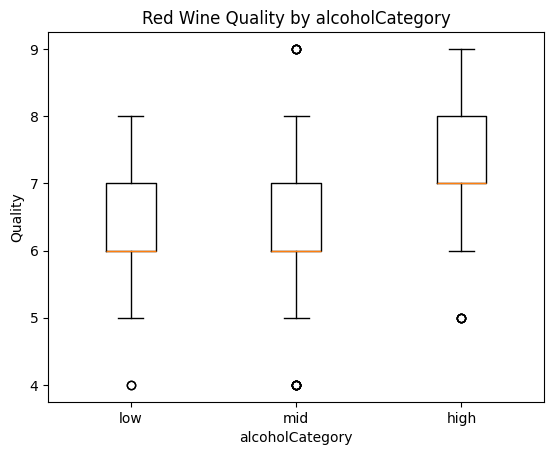

C:\Users\kjpho\AppData\Local\Temp\ipykernel_8612\1913608070.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(whiteQualityByCategory, labels=values)


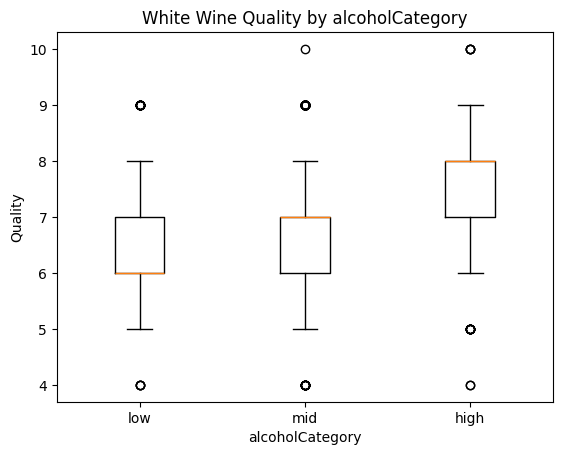

In [6]:
# Boxplot For Red Wine Quality By alcoholCategory
redQualityByCategory = [red.loc[red["alcohol_cat"] == cat, "quality"] for cat in values]
plt.figure()
plt.boxplot(redQualityByCategory, labels=values)
plt.title("Red Wine Quality by alcoholCategory")
plt.xlabel("alcoholCategory")
plt.ylabel("Quality")
plt.show()

# Boxplot For White Wine Quality By alcoholCategory
whiteQualityByCategory = [white.loc[white["alcohol_cat"] == cat, "quality"] for cat in values]
plt.figure()
plt.boxplot(whiteQualityByCategory, labels=values)
plt.title("White Wine Quality by alcoholCategory")
plt.xlabel("alcoholCategory")
plt.ylabel("Quality")
plt.show()

### 5.1 Conclusion

From this we can determine that there is a positive relationship between alcohol content and the quality of wine in both datasets. Wines in the high alcohol category consistently achieve higher average quality scores than those in the low and medium categories. Therefore this can suggest that alcohol content is an important factor in predicting wine quality. 


### 5.2 Visualisation Design

A boxplot was used to visualise the distribution of wine quality across alcohol categories. The primary marks in this visualisation are the boxes and whiskers, which represent the interquartile range and variability of the data. The x-axis encodes the categorical variable (alcohol category), while the y-axis represents the quality score.

This visualisation is effective because it clearly highlights differences in central tendency, spread, and outliers across categories. The side-by-side comparison allows for immediate identification of trends, particularly the increase in quality associated with higher alcohol levels.


## 6. Combining the Datasets

In [7]:
# Combine Datasets Into One 
red["type"] = "red"
white["type"] = "white"
combinedData = pd.concat([red, white], ignore_index=True, sort=False)

# Check Combined Dataset
print(combinedData.head())
print(combinedData.info())
print(combinedData.columns)
print(combinedData.describe())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality alcohol_cat type  
0      9.4        6         mid  red  
1      9

### 6.1 Combining The Data Sets

I ended up combining the data set into one to prepair it all for machine learning and the extension tasks.


## 7. Extension: Wine Type and Sweetness

### 7.1 Quality by Wine Type

        count      mean       std  min  25%  50%  75%   max
type                                                       
red    1599.0  6.636023  0.807569  4.0  6.0  7.0  7.0   9.0
white  4898.0  6.877909  0.885639  4.0  6.0  7.0  7.0  10.0


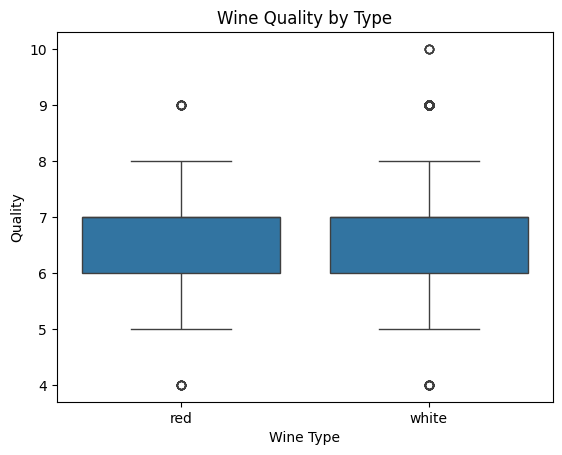

In [8]:
# Compare Quality By Wine Type
print(combinedData.groupby("type")["quality"].describe())

# Boxplot For Wine Quality By Type
plt.figure()
sns.boxplot(data=combinedData, x="type", y="quality")
plt.title("Wine Quality by Type")
plt.xlabel("Wine Type")
plt.ylabel("Quality")
plt.show()

The boxplot shows that both red and white wines have a similar overall distribution of quality scores, with most values falling between 6 and 7. This suggests that the majority of wines in both datasets are of average quality. 


### 7.2 Creating isSweet

In [9]:
# Check Columns For isSweet
print(combinedData.columns)

# Create isSweet Column Based On Residual Sugar
# A Wine Is Labelled As Sweet If Residual Sugar Is Above The Median Value In The Combined Dataset
combinedData["isSweet"] = combinedData["residual sugar"].apply(lambda x: 1 if x > combinedData["residual sugar"].median() else 0)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'alcohol_cat', 'type'],
      dtype='str')


For the isSweet variable it was calculated if it was above the median it would be sweet and if it wasn’t it wasn’t sweet. 

### 7.3 Quality by Sweetness

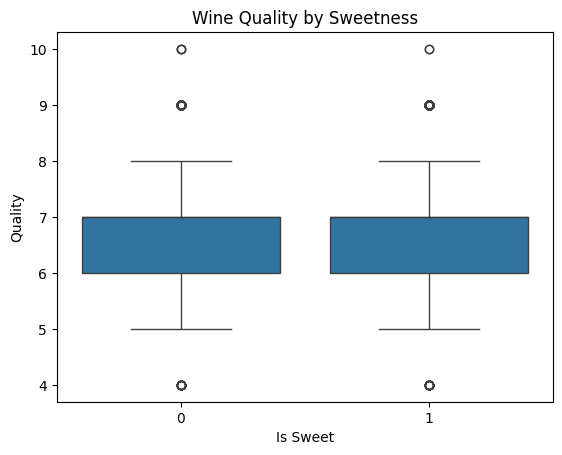

In [10]:
# Plot Quality By isSweet
plt.figure()
sns.boxplot(data=combinedData, x="isSweet", y="quality")
plt.title("Wine Quality by Sweetness")
plt.xlabel("Is Sweet")
plt.ylabel("Quality")
plt.show()

The boxplot is almost exact for the is sweet and is not sweet wines. It shows that most of the quality scores in between 6 and 7 meaning that sweetness doesn't actually change the wine quality overall.

### 7.4 Quality by Alcohol Category and Sweetness

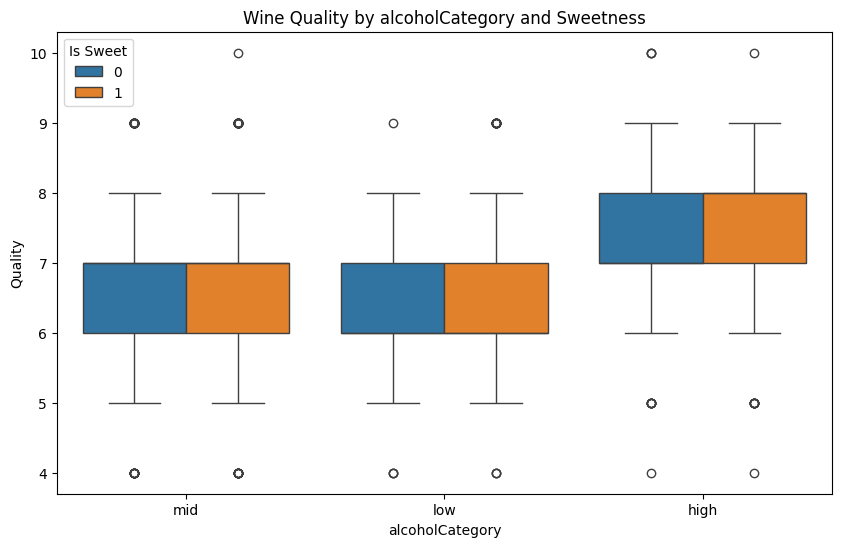

In [11]:
# Plot Quality By alcoholCategory And isSweet
plt.figure(figsize=(10, 6))
sns.boxplot(data=combinedData, x="alcohol_cat", y="quality", hue="isSweet")
plt.title("Wine Quality by alcoholCategory and Sweetness")
plt.xlabel("alcoholCategory")
plt.ylabel("Quality")
plt.legend(title="Is Sweet", loc="upper left")
plt.show()

This graph shows that when the alcohol category is higher the quality is also higher in both data sets regardless of it being sweet or not and regardless of it being red or white. 


## 8. Correlation Analysis and Variable Selection

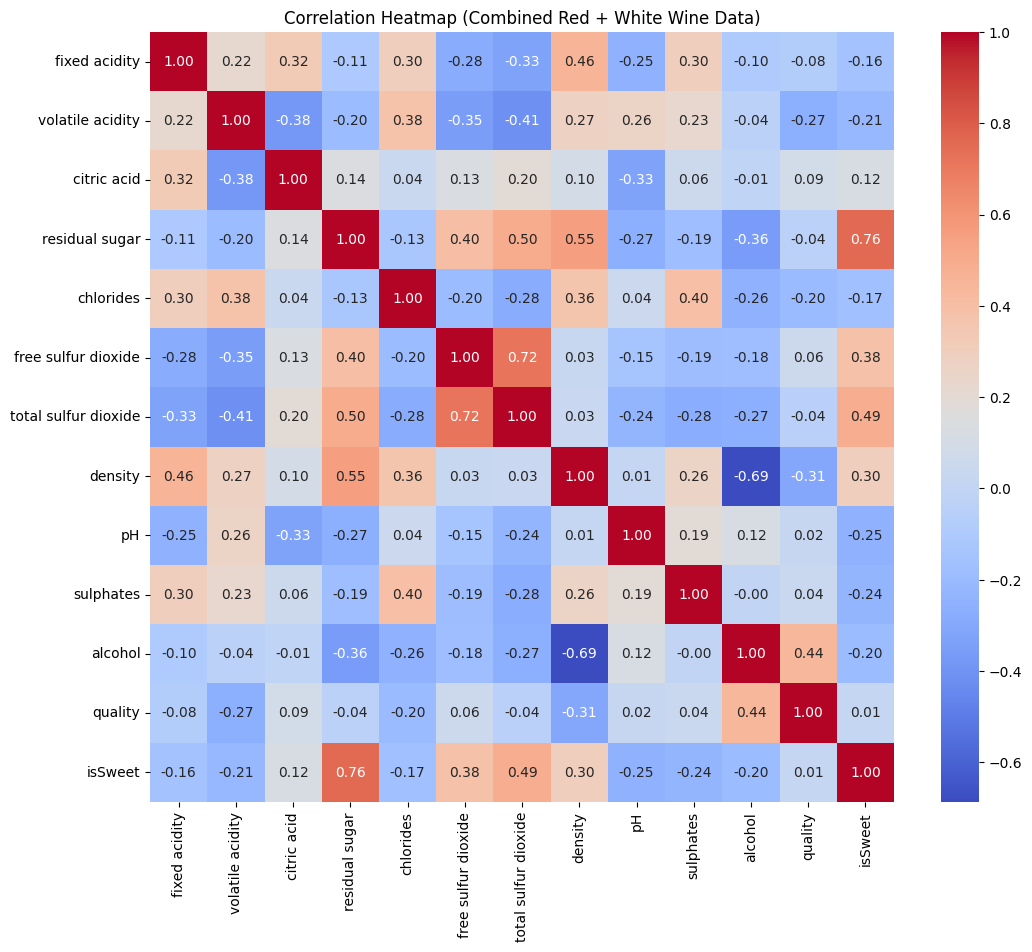

quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
isSweet                 0.012437
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


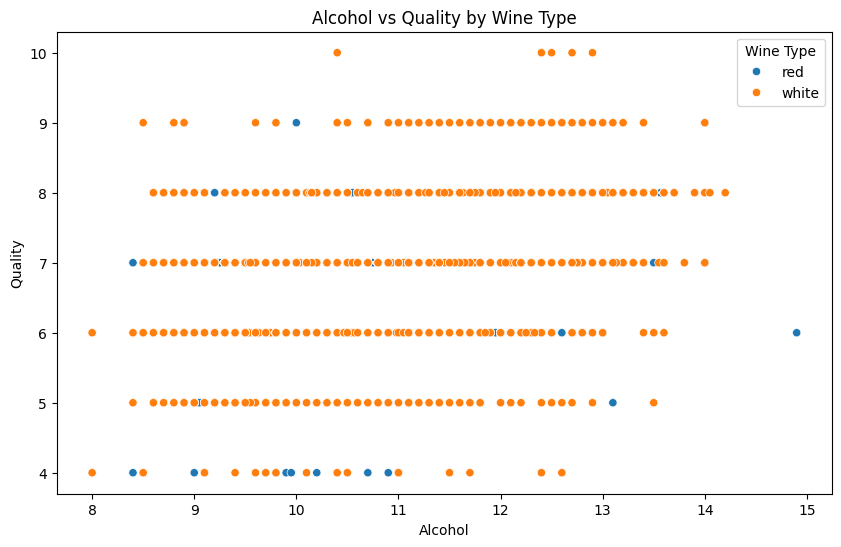

In [12]:
# Correlation Analysis On Combined Data
correlationCombinedMatrix = combinedData.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlationCombinedMatrix, cmap='coolwarm', annot=True, fmt='.2f')
plt.title("Correlation Heatmap (Combined Red + White Wine Data)")
plt.show()

# Correlation With Quality
qualityCorrelation = correlationCombinedMatrix["quality"].sort_values(ascending=False)
print(qualityCorrelation)

# Scatter Plot For Correlation With Quality
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combinedData, x="alcohol", y="quality", hue="type")
plt.title("Alcohol vs Quality by Wine Type")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.legend(title="Wine Type")
plt.show()

### 8.1 Analysis Of Heatmap

The correlation heatmap is very useful since it shows all the strongly correlated variables. It displays that alcohol has a decent correlation with quality, which supports the findings from the exploratory data analysis. Furthermore, volatile acidity displays a negative correlation with quality which can suggest that the higher acidity means a reduction in quality. 

### 8.2 Analysis Of Scatter Plot

The scatter plot shows a positive correlation between the alcohol content and the quality of the wine. As the alcohol levels increase so does the quality around above 11 percent. However, there is still quite a lot of overlap between quality which means that alcohol alone does not fully determine wine quality.

### 8.3 Use Of Visulisation

Heatmaps are used to show relationships between two variables, one plotted on each axis. By observing how cell colors change across each axis, you can observe if there are any patterns in value for one or both variables. It allows users to quickly spot strong positive or strong negative correlations between variables. The colour coded nature makes them easily interpretable by removing the need to read through tedious numerical tables. I would say this method of comparing the variables is way better than making a bunch of individual plots because you can easily see them all in one place at one time. 


## 9. Preparing Data for Machine Learning

### 9.1 Machine Learning Approach

For machine learning the data needs to be prepared for the two machine learning approaches which is linear regression and logistic regression. 

In [13]:
# Preparing Data For Machine Learning
X = combinedData.drop("quality", axis=1)
X = pd.get_dummies(X, drop_first=True)

# Regression Target
yRegression = combinedData["quality"]

## 10. Model 1: Linear Regression

In [14]:
# Split Into Training And Test Sets For Regression
xTrainRegression, xTestRegression, yTrainRegression, yTestRegression = train_test_split(X, yRegression, test_size=0.3, random_state=46)

# Initialise And Train The Linear Regression Model
modelLinearRegression = LinearRegression()
modelLinearRegression.fit(xTrainRegression, yTrainRegression)

# Make predictions
yPredictionTrainOfLinearRegression = modelLinearRegression.predict(xTrainRegression)
yPredictionTestOfLinearRegression = modelLinearRegression.predict(xTestRegression)

# Evaluate Linear Regression Model
rootMeanSquareErrorTrain = np.sqrt(mean_squared_error(yTrainRegression, yPredictionTrainOfLinearRegression))
rootMeanSquareErrorTest = np.sqrt(mean_squared_error(yTestRegression, yPredictionTestOfLinearRegression))

meanAbsoluteErrorTest = mean_absolute_error(yTestRegression, yPredictionTestOfLinearRegression)

print("Train Root Mean Square Error:", rootMeanSquareErrorTrain)
print("Test Root Mean Square Error:", rootMeanSquareErrorTest)
print("Test Mean Absolute Error:", meanAbsoluteErrorTest)

Train Root Mean Square Error: 0.7198406332514914
Test Root Mean Square Error: 0.7508830838136451
Test Mean Absolute Error: 0.5869202438190696


### 10.1 Linear Regression Model Explanation

Linear Regression is a fundamental supervised learning algorithm used to model the relationship between features and the target variable (quality). It predicts continuous values by fitting a straight line that best represents the data.

We train the model on the training set and evaluate it using Root Mean Squared Error (RMSE) (Square root of the residuals variance is RMSE. It describes how well the observed data points match the expected values or the model's absolute fit to the data) and Mean Absolute Error (MAE) (Calculates the accuracy of a regression model. MAE measures the average absolute difference between the predicted values and actual values). By comparing the train and test metrics it helps me assess whether the model is fit for this or is overfitting.


## 11. Model 2: Logistic Regression

In [15]:
# Classification Target
yClassification = combinedData["quality"].apply(lambda x: 1 if x >= 7 else 0)

# Split Into Training And Test Sets For Classification
xTrainClassification, xTestClassification, yTrainClassification, yTestClassification = train_test_split(X, yClassification, test_size=0.3, random_state=46)

# Initialise And Train The Logistic Regression Model
modelLogisticRegression = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])
modelLogisticRegression.fit(xTrainClassification, yTrainClassification)

# Make Predictions
yPredictionTrainOfLogisticRegression = modelLogisticRegression.predict(xTrainClassification)
yPredictionTestOfLogisticRegression = modelLogisticRegression.predict(xTestClassification)

# Evaluate Logistic Regression Model
accuracyTrain = accuracy_score(yTrainClassification, yPredictionTrainOfLogisticRegression)
accuracyTest = accuracy_score(yTestClassification, yPredictionTestOfLogisticRegression)

# Print Results For Logistic Regression Accuracy
print("Train Accuracy:", accuracyTrain)
print("Test Accuracy:", accuracyTest)

# Confusion Matrix For Logistic Regression
print("Confusion Matrix:")
print(confusion_matrix(yTestClassification, yPredictionTestOfLogisticRegression))

Train Accuracy: 0.7459863646360237
Test Accuracy: 0.7405128205128205
Confusion Matrix:
[[ 402  309]
 [ 197 1042]]


### 11.1 Logistic Regression for Binary Classification

Logistic regression estimates the probability of an event occurring based on a the data sets to predict whether a wine is high or low quality. Logistic Regression was used as a classification model, where wine quality was converted into binary labels using a threshold (quality ≥ 7 = high, < 7 = low).


## 12. Extension: Classification Threshold Experiments

In [16]:
# Compare Different Classification Thresholds
for threshold in [6, 7, 8]:
    # Classification Target Based On Threshold
    yClassificationThreshold = combinedData["quality"].apply(lambda x: 1 if x >= threshold else 0)
    
    # Split Into Training And Test Sets For Threshold
    xTrainThreshold, xTestThreshold, yTrainThreshold, yTestThreshold = train_test_split(X, yClassificationThreshold, test_size=0.3, random_state=46)
    
    # Initialise And Train The Logistic Regression Model For Threshold
    modelLogisticRegressionThreshold = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ])
    modelLogisticRegressionThreshold.fit(xTrainThreshold, yTrainThreshold)
    
    # Make Predictions For Threshold
    yPredictionTrainOfLogisticRegressionThreshold = modelLogisticRegressionThreshold.predict(xTrainThreshold)
    yPredictionTestOfLogisticRegressionThreshold = modelLogisticRegressionThreshold.predict(xTestThreshold)
    
    # Evaluate Logistic Regression Model For Threshold
    accuracyTrainThreshold = accuracy_score(yTrainThreshold, yPredictionTrainOfLogisticRegressionThreshold)
    accuracyTestThreshold = accuracy_score(yTestThreshold, yPredictionTestOfLogisticRegressionThreshold)

    # Print Results For Threshold
    print("Threshold:", threshold)
    print("Train Accuracy:", accuracyTrainThreshold)
    print("Test Accuracy:", accuracyTestThreshold)

    # Confusion Matrix For Threshold
    print("Confusion Matrix:")
    print(confusion_matrix(yTestThreshold, yPredictionTestOfLogisticRegressionThreshold))

Threshold: 6
Train Accuracy: 0.9656916648339564
Test Accuracy: 0.9564102564102565
Confusion Matrix:
[[   2   83]
 [   2 1863]]
Threshold: 7
Train Accuracy: 0.7459863646360237
Test Accuracy: 0.7405128205128205
Confusion Matrix:
[[ 402  309]
 [ 197 1042]]
Threshold: 8
Train Accuracy: 0.825819221464702
Test Accuracy: 0.8117948717948718
Confusion Matrix:
[[1486   72]
 [ 295   97]]


### 12.1 Exploring Classification Thresholds

I ended up testing multiple thresholds because this can help me understand how changing the threshold for high quality affects the performance of the model.


## 13. Extension: With and Without Wine Type

In [17]:
# Preparing Data Without Wine Type
XWithoutType = combinedData.drop(["quality", "type"], axis=1)
XWithoutType = pd.get_dummies(XWithoutType, drop_first=True)

# Split Into Training And Test Sets Without Wine Type
xTrainWithoutType, xTestWithoutType, yTrainWithoutType, yTestWithoutType = train_test_split(XWithoutType, yRegression, test_size=0.3, random_state=46)

# Linear Regression Without Wine Type
modelLinearRegressionWithoutType = LinearRegression()
modelLinearRegressionWithoutType.fit(xTrainWithoutType, yTrainWithoutType)

# Make Predictions Without Wine Type
yPredictionTrainOfLinearRegressionWithoutType = modelLinearRegressionWithoutType.predict(xTrainWithoutType)
yPredictionTestOfLinearRegressionWithoutType = modelLinearRegressionWithoutType.predict(xTestWithoutType)

# Evaluate Linear Regression Without Wine Type
print("Without Wine Type Train Root Mean Squared Error:", np.sqrt(mean_squared_error(yTrainWithoutType, yPredictionTrainOfLinearRegressionWithoutType)))
print("Without Wine Type Test Root Mean Squared Error:", np.sqrt(mean_squared_error(yTestWithoutType, yPredictionTestOfLinearRegressionWithoutType)))
print("Without Wine Type Test Mean Absolute Error:", mean_absolute_error(yTestWithoutType, yPredictionTestOfLinearRegressionWithoutType))

Without Wine Type Train Root Mean Squared Error: 0.7218733654587682
Without Wine Type Test Root Mean Squared Error: 0.75232651891584
Without Wine Type Test Mean Absolute Error: 0.5874740607933004


## 14. Extension: Selected Feature Model

In [18]:
# Selected Features Based On Correlation Analysis
selectedFeatures = ["alcohol", "volatile acidity", "sulphates", "residual sugar", "density"]

# Prepare Data With Selected Features
XSelected = combinedData[selectedFeatures]
YSelected = combinedData["quality"]

# Split Into Training And Test Sets For Selected Features
xTrainSelected, xTestSelected, yTrainSelected, yTestSelected = train_test_split(XSelected, YSelected, test_size=0.3, random_state=46)

# Linear Regression With Selected Features
modelLinearRegressionSelected = LinearRegression()
modelLinearRegressionSelected.fit(xTrainSelected, yTrainSelected)

# Make Predictions For Selected Features
yPredictionTrainOfLinearRegressionSelected = modelLinearRegressionSelected.predict(xTrainSelected)
yPredictionTestOfLinearRegressionSelected = modelLinearRegressionSelected.predict(xTestSelected)

# Evaluate Linear Regression Model With Selected Features
print("Selected Feature Train Root Mean Squared Error:", np.sqrt(mean_squared_error(yTrainSelected, yPredictionTrainOfLinearRegressionSelected)))
print("Selected Feature Test Root Mean Squared Error:", np.sqrt(mean_squared_error(yTestSelected, yPredictionTestOfLinearRegressionSelected)))
print("Selected Feature Test Mean Absolute Error:", mean_absolute_error(yTestSelected, yPredictionTestOfLinearRegressionSelected))

Selected Feature Train Root Mean Squared Error: 0.7340044034029877
Selected Feature Test Root Mean Squared Error: 0.7606412660912155
Selected Feature Test Mean Absolute Error: 0.5940970680946488


### 14.1 Feature Selection

The selected features consists of variables that correlated with quality. Furthermore, using variables that are uncorrelated with the outcome is generally not useful and using variables that have very small variance across the training set is not useful.




## 15. Extension: Comparing Correlated Variables

In [19]:
# Compare Residual Sugar Only
xResidualSugar = combinedData[["residual sugar"]]
yResidualSugar = combinedData["quality"]

# Split Into Training And Test Sets For Residual Sugar
xTrainResidualSugar, xTestResidualSugar, yTrainResidualSugar, yTestResidualSugar = train_test_split(xResidualSugar, yResidualSugar, test_size=0.3, random_state=46)

# Linear Regression With Residual Sugar Only
modelLinearRegressionResidualSugar = LinearRegression()
modelLinearRegressionResidualSugar.fit(xTrainResidualSugar, yTrainResidualSugar)

# Make Predictions For Residual Sugar Only
yPredictionTrainOfLinearRegressionResidualSugar = modelLinearRegressionResidualSugar.predict(xTrainResidualSugar)
yPredictionTestOfLinearRegressionResidualSugar = modelLinearRegressionResidualSugar.predict(xTestResidualSugar)

# Evaluate Linear Regression Model For Residual Sugar Only
print("Residual Sugar Only Test Root Mean Squared Error:", np.sqrt(mean_squared_error(yTestResidualSugar, yPredictionTestOfLinearRegressionResidualSugar)))
print("Residual Sugar Only Test Mean Absolute Error:", mean_absolute_error(yTestResidualSugar, yPredictionTestOfLinearRegressionResidualSugar))

# Compare Density Only
xDensity = combinedData[["density"]]
yDensity = combinedData["quality"]      

# Split Into Training And Test Sets For Density
xTrainDensity, xTestDensity, yTrainDensity, yTestDensity = train_test_split(xDensity, yDensity, test_size=0.3, random_state=46)

# Linear Regression With Density Only
modelLinearRegressionDensity = LinearRegression()
modelLinearRegressionDensity.fit(xTrainDensity, yTrainDensity)

# Make Predictions For Density Only
yPredictionTrainOfLinearRegressionDensity = modelLinearRegressionDensity.predict(xTrainDensity)
yPredictionTestOfLinearRegressionDensity = modelLinearRegressionDensity.predict(xTestDensity)

# Evaluate Linear Regression Model For Density Only
print("Density Only Test Root Mean Squared Error:", np.sqrt(mean_squared_error(yTestDensity, yPredictionTestOfLinearRegressionDensity)))
print("Density Only Test Mean Absolute Error:", mean_absolute_error(yTestDensity, yPredictionTestOfLinearRegressionDensity))

Residual Sugar Only Test Root Mean Squared Error: 0.8854500569571708
Residual Sugar Only Test Mean Absolute Error: 0.6934105494501529
Density Only Test Root Mean Squared Error: 0.8521480717471424
Density Only Test Mean Absolute Error: 0.6675876542010875


## 16. Extension: Predicting All Quality Labels

In [20]:
# Predict All Quality Labels
yAllQualityLabels = combinedData["quality"]

# Split Into Training And Test Sets For All Quality Labels
xTrainAllLabels, xTestAllLabels, yTrainAllLabels, yTestAllLabels = train_test_split(X, yAllQualityLabels, test_size=0.3, random_state=46)

# Initialise And Train The Logistic Regression Model For All Quality Labels
modelAllLabels = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])
modelAllLabels.fit(xTrainAllLabels, yTrainAllLabels)

# Make Predictions For All Quality Labels
yPredictionTrainOfLogicRegressionAllLabels = modelAllLabels.predict(xTrainAllLabels)
yPredictionTestOfLogicRegressionAllLabels = modelAllLabels.predict(xTestAllLabels)

# Evaluate Logistic Regression Model For All Quality Labels
print("All Label Train Accuracy:", accuracy_score(yTrainAllLabels, yPredictionTrainOfLogicRegressionAllLabels))
print("All Label Test Accuracy:", accuracy_score(yTestAllLabels, yPredictionTestOfLogicRegressionAllLabels))
print("Confusion Matrix:")
print(confusion_matrix(yTestAllLabels, yPredictionTestOfLogicRegressionAllLabels))

All Label Train Accuracy: 0.5526720914888937
All Label Test Accuracy: 0.5317948717948718
Confusion Matrix:
[[  1   0   6   3   1   0   0]
 [  0   1  46  27   0   0   0]
 [  0   2 383 240   1   0   0]
 [  0   1 207 581  58   0   0]
 [  0   0  20 242  71   0   0]
 [  0   0   1  45  12   0   0]
 [  0   0   0   0   1   0   0]]


### 16.1 Multiclass Classification 

This was done to try and predict all quality labels as opposed to just "low" and "high". 


## 17. Extension: Interactive Visualisation

In [21]:
# Interactive Alcohol And Quality Plot
alt.data_transformers.disable_max_rows()
alt.renderers.enable("default")

chart = alt.Chart(combinedData).mark_circle(size=60).encode(
    x="alcohol",
    y="quality",
    color="type",
    tooltip=["alcohol", "quality", "type", "volatile acidity"]
).interactive()

chart

alt.Chart(...)

### 17.1 Interactive Data Exploration

This was a lot more useful then using a non interactive chart as it lets you move around and see more points and get the accurate alcohol and quality value for each point. You can also see some points that were hidden behind others now. 


## 18. Results Summary

### 18.1 Summary of Experiments

The following table summarizes the performance metrics for all the models I tested. 

| Model / Experiment                  |  Training Result |               Test Result | Interpretation                                                  |
| ----------------------------------- | ---------------: | ------------------------: | --------------------------------------------------------------- |
| Linear Regression                   |     RMSE = 0.720 | RMSE = 0.751, MAE = 0.587 | Good baseline model with similar train/test results             |
| Logistic Regression, threshold ≥ 7  | Accuracy = 0.746 |          Accuracy = 0.741 | Best balanced classification threshold                          |
| Logistic Regression, threshold ≥ 6  | Accuracy = 0.966 |          Accuracy = 0.956 | Misleading because most wines are classed as high quality       |
| Logistic Regression, threshold ≥ 8  | Accuracy = 0.826 |          Accuracy = 0.812 | Reasonable accuracy, but struggles with rare high-quality wines |
| Linear Regression without wine type |     RMSE = 0.722 |              RMSE = 0.752 | Very similar to the full model, so wine type added little value |
| Selected feature Linear Regression  |     RMSE = 0.734 |              RMSE = 0.761 | Slightly worse, but still reasonable                            |
| Logistic Regression, all labels     | Accuracy = 0.553 |          Accuracy = 0.532 | Much harder due to class imbalance                              |


## 19. Final Conclusion

The analysis showed that most wines were concentrated around middle quality scores. Alcohol content had one of the clearest positive relationships with wine quality, especially in the alcohol category analysis. Logistic Regression was useful for binary classification, while predicting all quality labels was harder because some scores were rare. The train and test results were compared to check whether the models generalised well. Future improvements could include cross-validation, hyperparameter tuning, and testing more advanced models.